In [ ]:
import torch
from PIL import Image
from lang_sam import LangSAM
import torch
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from rasterio.windows import Window



model = LangSAM() # takes long first run


In [ ]:
import numpy as np
import rasterio
from rasterio.windows import Window
from PIL import Image

def get_full_mask_fast(model, image_bytes, keyword="tree", patch_size=1024, overlap=128, text_threshold=0.15):
    stride = patch_size - overlap
    with rasterio.MemoryFile(image_bytes) as memfile, memfile.open() as src:
        h, w = src.height, src.width
        full_mask = np.zeros((h, w), dtype=bool)
        
        for y in range(0, h, stride):
            for x in range(0, w, stride):
                th, tw = min(patch_size, h - y), min(patch_size, w - x)
                
                # read and format patch
                patch = src.read([1, 2, 3], window=Window(x, y, tw, th))
                patch = np.moveaxis(patch, 0, -1)
                
                if patch.dtype == np.uint16:
                    patch = (patch >> 8).astype(np.uint8) # same as patch / 256
                
                try:
                    # Predict and extract safely using .get()
                    res = model.predict([Image.fromarray(patch)], [keyword], text_threshold=text_threshold)
                    masks = res[0].get('masks') if res else None
                    
                    if masks is not None and len(masks) > 0:
                        # tensor conversion
                        m_np = masks.cpu().numpy() if hasattr(masks, 'cpu') else masks
                        c_mask = np.any(m_np, axis=0) if m_np.ndim == 3 else m_np
                        
                        # Resize if necessary for edges
                        if c_mask.shape != (th, tw):
                            c_mask = np.array(Image.fromarray(c_mask).resize((tw, th), Image.NEAREST))
                        
                        full_mask[y:y+th, x:x+tw] |= c_mask.astype(bool)
                        
                except Exception as e:
                    print(f"skipping tile at {x},{y}: {e}") 

        return full_mask.astype(np.uint8) * 255 
            

In [ ]:
image_path = "dop10rgbi_32_280_5652_1_nw_2025.jp2"

with open(image_path, "rb") as f:
    img_bytes = f.read()
    
masks = get_full_mask_fast(
    model = model,
    image_bytes = img_bytes,
    keyword="tree",
    patch_size=1024,
    overlap=128,
    text_threshold=0.15
)

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

def plot_overview_and_roi(image_path, full_mask_array, roi_x=2000, roi_y=3000, roi_size=1024, scale_factor=0.2):
    img = Image.open(image_path).convert("RGB")
    new_w = int(img.width * scale_factor)
    new_h = int(img.height * scale_factor)
    img_small = img.resize((new_w, new_h), Image.Resampling.LANCZOS)
    mask_small = Image.fromarray(full_mask_array).resize((new_w, new_h), Image.Resampling.NEAREST)
    
    roi_img = img.crop((roi_x, roi_y, roi_x + roi_size, roi_y + roi_size))
    roi_mask = full_mask_array[roi_y:roi_y + roi_size, roi_x:roi_x + roi_size]

    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    # The whole downscaled image
    axes[0].imshow(img_small)
    axes[0].imshow(np.array(mask_small), cmap='jet', alpha=0.4)
    axes[0].axis('off')
    axes[0].set_title("Overview (downscaled)")
    
    # Region of interest 
    bx = [roi_x * scale_factor, (roi_x + roi_size) * scale_factor, (roi_x + roi_size) * scale_factor, roi_x * scale_factor, roi_x * scale_factor]
    by = [roi_y * scale_factor, roi_y * scale_factor, (roi_y + roi_size) * scale_factor, (roi_y + roi_size) * scale_factor, roi_y * scale_factor]
    axes[0].plot(bx, by, color='red', linewidth=2)
    
    axes[1].imshow(roi_img)
    axes[1].imshow(roi_mask, cmap='jet', alpha=0.4)
    axes[1].axis('off')
    axes[1].set_title("Region of interest")
    
    plt.show()

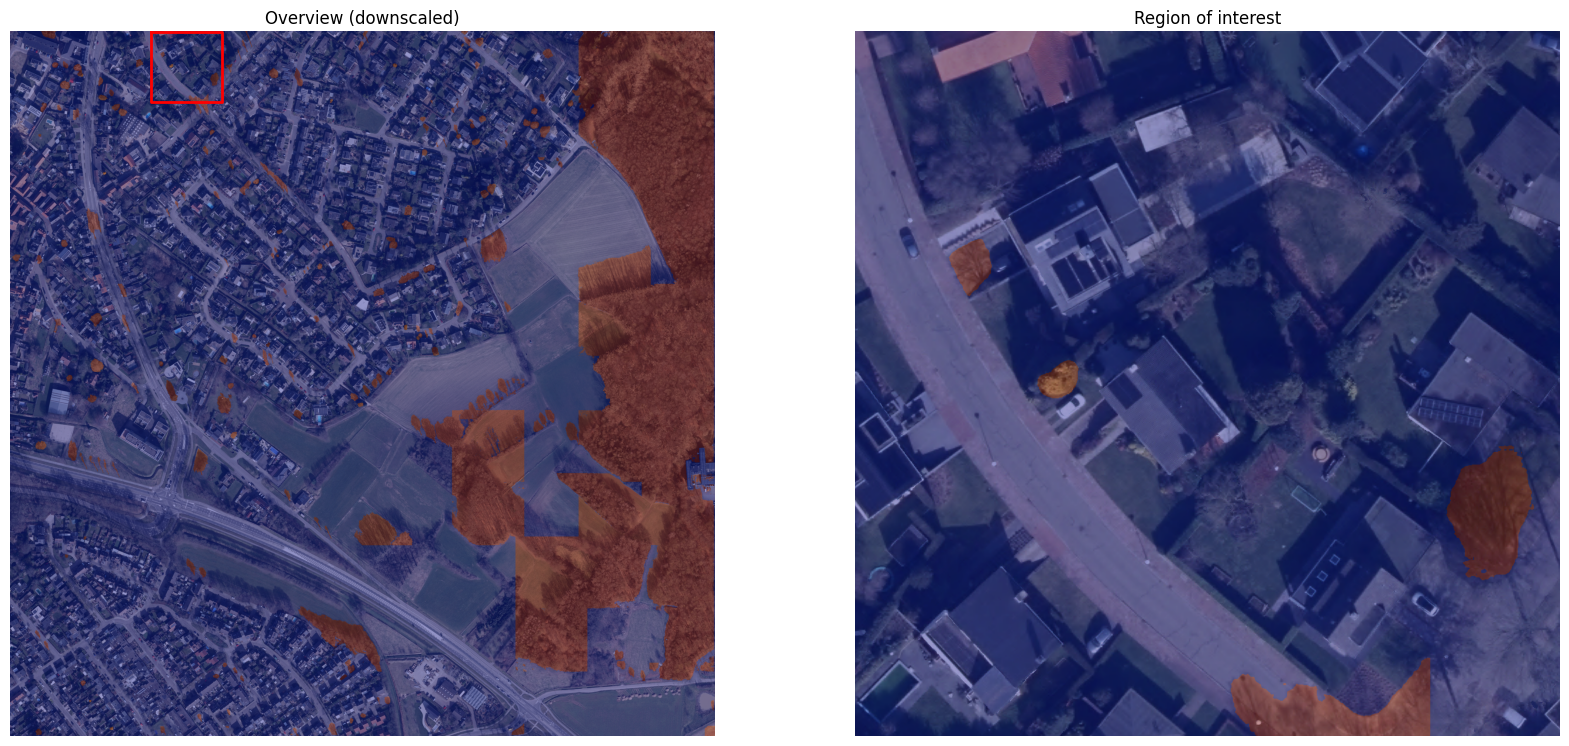

In [50]:
plot_overview_and_roi(image_path, masks, roi_x=2000, roi_y=0, roi_size=1000, scale_factor=0.2) # 10%

In [ ]:
masks_solar = get_full_mask_fast(
    model = model,
    image_bytes = img_bytes,
    keyword="solar panel",
    patch_size=1024,
    overlap=128,
    text_threshold=0.15
)

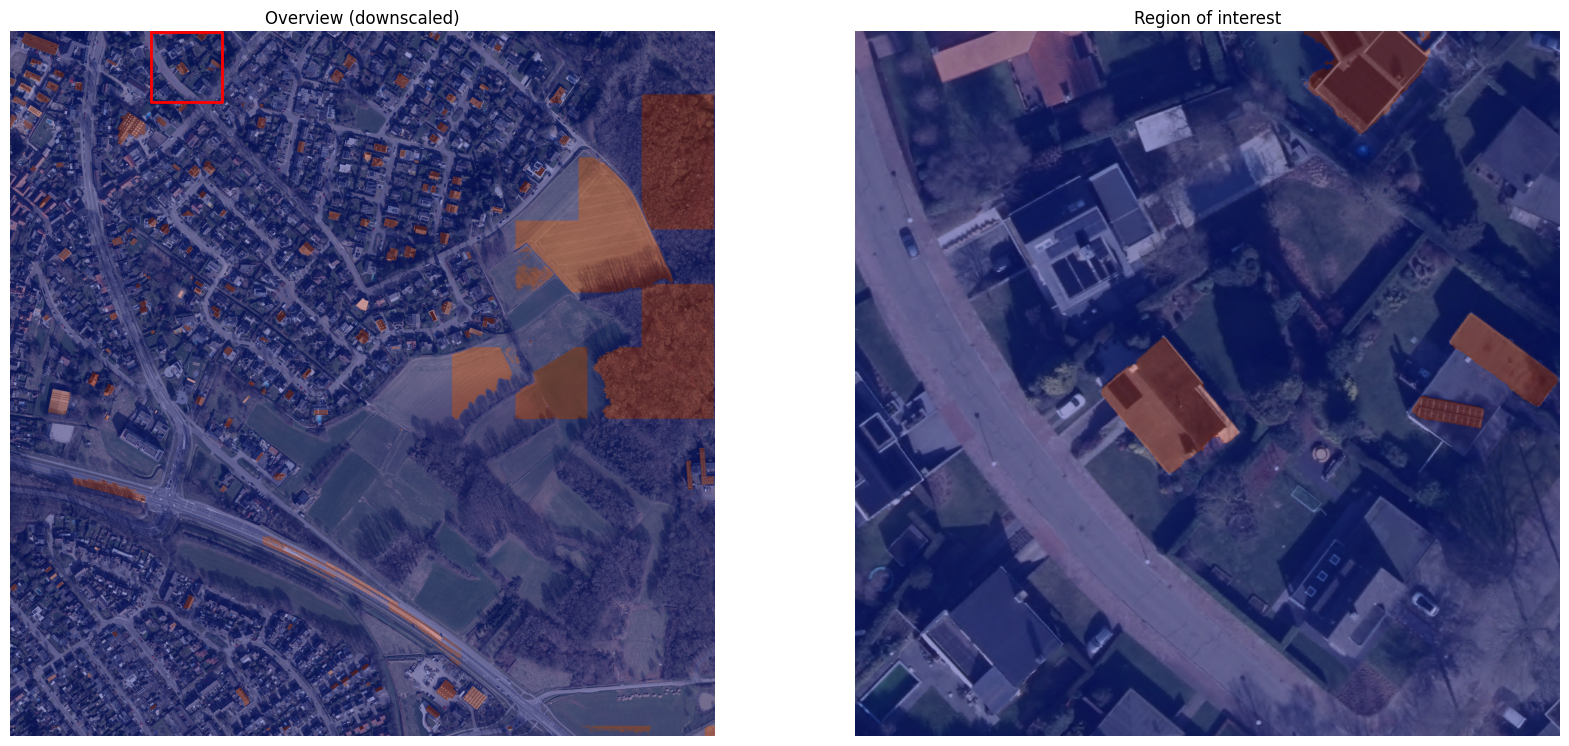

In [51]:

plot_overview_and_roi(image_path, masks_solar, roi_x=2000, roi_y=0, roi_size=1000, scale_factor=0.2)